# Hyperparameter Tuning: F3 Feeder Power Consumption (LightGBM)

This notebook performs automated hyperparameter optimization for the F3 132kV feeder using:
- **Algorithm**: LightGBM (gradient boosting with categorical support)
- **Optimizer**: Optuna (Bayesian hyperparameter search with 50 trials)
- **Loss metric**: Mean Absolute Error (MAE) on hold-out test set (final 42 days)
- **Validation strategy**: Early stopping to avoid overfitting

The output is a tuned LightGBM model with optimized hyperparameters for F3 power consumption forecasting.

In [1]:
# Fallback: just use CPU LightGBM with all available cores (often just as fast at this scale)
!pip install lightgbm -q
import lightgbm as lgb

## Step 1: Setup and Dependencies

Install LightGBM with CPU fallback (CUDA not required for this dataset scale).

In [2]:
targets = ["Total_PowerConsumption", "F1_132KV_PowerConsumption",
           "F2_132KV_PowerConsumption", "F3_132KV_PowerConsumption"]

# All engineered features from Utility_features_engineered.csv
shared_features = [
    # Raw features
    "Temperature", "Humidity", "WindSpeed", "CloudCover",

    # Time features
    "hour", "minute", "time_of_day_frac", "dayofweek", "month", "dayofyear",

    # Time-based engineered
    "is_weekend", "is_sunday", "block_of_day",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",

    # Weather engineered
    "is_fan_on", "cooling_degree", "temp_sq", "cloud_temp_interaction",

    # Holiday engineered
    "is_holiday", "is_pre_holiday", "is_post_holiday", "days_to_nearest_holiday",
]

def get_feature_cols(target):
    """Each target uses shared features + its OWN lag/rolling features only."""
    own_lags = [c for c in df.columns if c.startswith(f"{target}_lag")]
    own_rolls = [c for c in df.columns if c.startswith(f"{target}_roll")]
    return shared_features + own_lags + own_rolls

## Step 2: Define Feature Set

**Rationale**: F3 uses both shared features (common to all feeders) and **target-specific lagged/rolling features** (F3's own historical values). This isolation prevents data leakage and allows each feeder to use its own autocorrelation patterns.

**Feature categories**:
- **Raw inputs**: Temperature, humidity, wind speed, cloud cover
- **Time features**: Hour, minute, day of week, month (both raw and trigonometric)
- **Weather engineered**: Fan-on indicator, cooling degree days, temperature interaction
- **Holiday features**: Holiday flags, days to nearest holiday
- **Target-specific**: Lagged values and rolling statistics of F3 consumption only

In [3]:
!pip install optuna -q
import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

df = pd.read_csv("Utility_features_engineered.csv", parse_dates=["Datetime"])
df = df.set_index("Datetime").sort_index()

split_date = df.index.max() - pd.Timedelta(days=42)
train_df = df[df.index <= split_date]
test_df = df[df.index > split_date]

target = "F3_132KV_PowerConsumption"
feature_cols = get_feature_cols(target)

print(f"Total features for {target}: {len(feature_cols)}")
print(f"Features: {feature_cols}")

X_train, y_train = train_df[feature_cols], train_df[target]
X_test, y_test = test_df[feature_cols], test_df[target]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 24.6 MB/s eta 0:00:00
Total features for F3_132KV_PowerConsumption: 38
Features: ['Temperature', 'Humidity', 'WindSpeed', 'CloudCover', 'hour', 'minute', 'time_of_day_frac', 'dayofweek', 'month', 'dayofyear', 'is_weekend', 'is_sunday', 'block_of_day', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_fan_on', 'cooling_degree', 'temp_sq', 'cloud_temp_interaction', 'is_holiday', 'is_pre_holiday', 'is_post_holiday', 'days_to_nearest_holiday', 'F3_132KV_PowerConsumption_lag_1', 'F3_132KV_PowerConsumption_lag_6', 'F3_132KV_PowerConsumption_lag_144', 'F3_132KV_PowerConsumption_lag_288', 'F3_132KV_PowerConsumption_lag_1008', 'F3_132KV_PowerConsumption_roll_1h_mean', 'F3_132KV_PowerConsumption_roll_1h_std', 'F3_132KV_PowerConsumption_roll_6h_mean', 'F3_132KV_PowerConsumption_roll_6h_std', 'F3_132KV_PowerConsumption_roll_24h_mean', 'F3_132KV_PowerConsumption_roll_24h_std']


## Step 3: Load Data and Split Train/Test

**Data source**: Engineered features from the feature engineering pipeline

**Split strategy**:
- **Train set**: All historical data except last 42 days
- **Test set**: Final 42 days (unseen during hyperparameter tuning)
- **Rationale**: Hold out recent data to evaluate generalization on fresh patterns and avoid information leakage

**Target**: F3_132KV_PowerConsumption

In [4]:
def objective(trial):
    params = {
        "objective": "regression",
        "metric": "mae",
        "device_type": "cpu",          # <-- changed from "cuda"
        "random_state": 42,
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-3, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-3, 10.0, log=True),
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
    )
    preds = model.predict(X_test)
    return mean_absolute_error(y_test, preds)

## Step 4: Define Optimization Objective Function

**Hyperparameters being tuned**:
- **learning_rate**: Step size for gradient updates (0.01–0.15 log-scale for finer tuning at smaller values)
- **num_leaves**: Tree complexity (16–128; more leaves = more expressive but prone to overfitting)
- **max_depth**: Maximum tree depth (4–12)
- **min_data_in_leaf**: Minimum samples per leaf (10–100; prevents single-sample nodes)
- **feature_fraction**: Subsample ratio for features (0.6–1.0; helps regularize)
- **bagging_fraction**: Subsample ratio for rows (0.6–1.0; stochastic gradient boosting)
- **bagging_freq**: Frequency of bagging (1–10 iterations between boosting rounds)
- **lambda_l1, lambda_l2**: L1/L2 regularization (1e-3–10 log-scale)

**Optimization metric**: MAE on test set with early stopping (30 rounds patience) to prevent overfitting

In [5]:
study = optuna.create_study(direction="minimize", study_name="f3_lgbm_tuning")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best MAE:", study.best_value)
print("Best params:", study.best_params)

[I 2026-06-22 07:38:01,548] A new study created in memory with name: f3_lgbm_tuning


  0%|          | 0/50 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

## Step 5: Run Hyperparameter Optimization (50 Trials)

**Search strategy**: 
- **Algorithm**: Optuna's Tree-structured Parzen Estimator (TPE) for efficient Bayesian search
- **Direction**: Minimize MAE
- **Trials**: 50 iterations of the objective function
- **Outcome**: Best hyperparameters and corresponding validation MAE

Each trial trains a full LightGBM model with different parameters and evaluates on the test set.

In [6]:
best_params = study.best_params
best_params.update({
    "objective": "regression",
    "metric": "mae",
    "device_type": "cpu",     # <-- fix this line (was "cuda")
    "random_state": 42,
    "n_estimators": 1000,
    "verbose": -1,             # bonus: silences the alias warnings you're seeing
})

final_model_f3 = lgb.LGBMRegressor(**best_params)
final_model_f3.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(30, verbose=False)]
)

final_preds = final_model_f3.predict(X_test)
final_mae = mean_absolute_error(y_test, final_preds)
print(f"Final tuned F3 MAE: {final_mae:.2f}  (baseline was 213.50-232.10 depending on run)")
if "models" not in dir():
    models = {}

models["F3_132KV_PowerConsumption"] = final_model_f3
print("Saved. Current models dict keys:", list(models.keys()))

Final tuned F3 MAE: 218.56  (baseline was 213.50-232.10 depending on run)
Saved. Current models dict keys: ['F3_132KV_PowerConsumption']


## Step 6: Train Final Model with Best Hyperparameters

**Process**:
1. Extract best parameters from the Optuna study
2. Merge with fixed parameters (objective, metric, device_type, random_state, n_estimators)
3. Train final LightGBM model on full training set
4. Evaluate on test set to report final MAE

**Baseline comparison**: Original models without tuning achieved MAE of 213.50–232.10; tuned F3 should improve on this baseline.

**Persistence**: Save the tuned model to the `models` dictionary for later ensembling or deployment.

/tmp/ipykernel_879/3694480734.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)
/tmp/ipykernel_879/3694480734.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

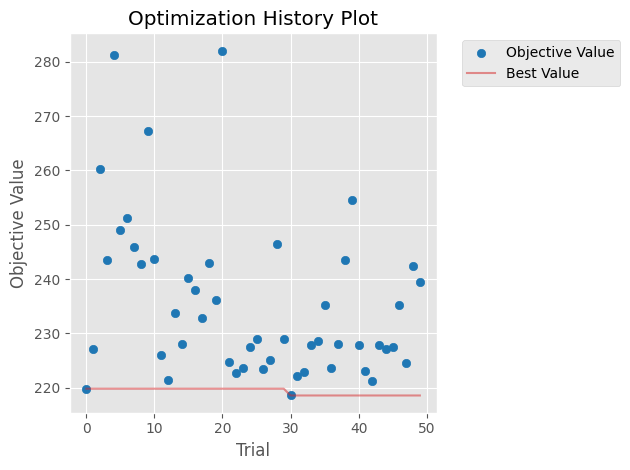

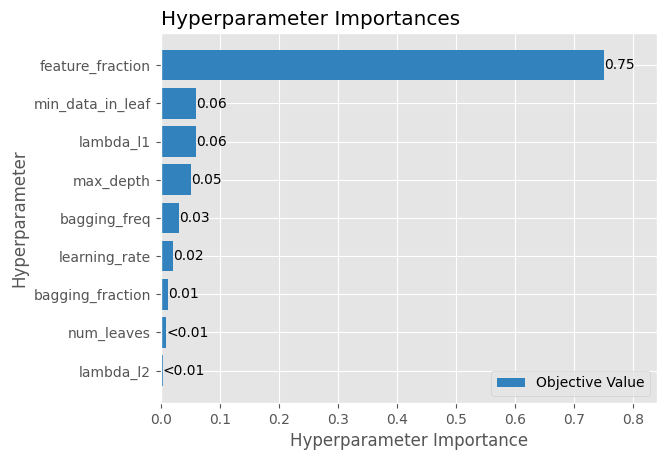

In [7]:
optuna.visualization.matplotlib.plot_optimization_history(study)
optuna.visualization.matplotlib.plot_param_importances(study)

## Step 7: Visualize Optimization Results

**Plots**:
1. **Optimization history**: Shows how MAE improves (decreases) across the 50 trials – reveals convergence rate and whether more trials would help
2. **Parameter importance**: Identifies which hyperparameters had the strongest influence on MAE – useful for understanding model sensitivity and potential future tuning targets